In [1]:
from google.colab import files
uploaded = files.upload()

Saving Video Games Sales (1980-2024) - Raw.csv to Video Games Sales (1980-2024) - Raw.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Video Games Sales (1980-2024) - Raw.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [3]:
# Missing Values Check

df.isnull().sum().sort_values(ascending=False)

,0
critic_score,57338
jp_sales,57290
na_sales,51379
pal_sales,51192
other_sales,48888
last_update,46137
total_sales,45094
release_date,7051
developer,17
publisher,0


In [4]:
# Data Duplication

df.duplicated().sum()

np.int64(0)

In [5]:
# Outlier Check

## Total Sales Data Check
print(df['total_sales'].describe())

## Total Sales vs Regional Sales Check
total_regional_sales = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df['regional_sales_calculated'] = df[total_regional_sales].sum(axis=1)

df['sales_diff'] = (df['total_sales'] - df['regional_sales_calculated']).abs()

invalid_data = df[df['sales_diff'] >= 0.025]

print(f"Number of Sales Data Anomaly: {len(invalid_data)}")
if len(invalid_data) > 0:
    print("Sample of Sales Data Anomaly:")
    print(invalid_data[['total_sales', 'regional_sales_calculated', 'sales_diff']].head())

## Critic Score
critic_score_anomaly = df[(df['critic_score'] < 0) | (df['critic_score'] > 10)]
print(f"Anomaly: {len(critic_score_anomaly)}")

count    18922.000000
mean         0.349113
std          0.807462
min          0.000000
25%          0.030000
50%          0.120000
75%          0.340000
max         20.320000
Name: total_sales, dtype: float64
Number of Sales Data Anomaly: 0
Anomaly: 0


In [6]:
# Missing Value Handling (Dropped by Release Date Unavailable)

df = df.dropna(subset=['total_sales'])
df = df.dropna(subset=['release_date'])
df = df.reset_index(drop=True)

print(f"Number of Row After NA: {len(df)}")
print(f"Number of NA in total sales: {df['total_sales'].isna().sum()}")
print(f"Number of NA in release_date: {df['release_date'].isna().sum()}")

df.info()

Number of Row After NA: 18832
Number of NA in total sales: 0
Number of NA in release_date: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   img                        18832 non-null  object 
 1   title                      18832 non-null  object 
 2   console                    18832 non-null  object 
 3   genre                      18832 non-null  object 
 4   publisher                  18832 non-null  object 
 5   developer                  18829 non-null  object 
 6   critic_score               4123 non-null   float64
 7   total_sales                18832 non-null  float64
 8   na_sales                   12620 non-null  float64
 9   jp_sales                   6688 non-null   float64
 10  pal_sales                  12776 non-null  float64
 11  other_sales                15071 non-null  float64
 12  release_d

In [7]:
# Missing Value (Replacement)

df['developer'] = df['developer'].fillna('Unknown')
print(f"Jumlah baris kosong di kolom developer: {df['developer'].isna().sum()}")

df.info()

Jumlah baris kosong di kolom developer: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   img                        18832 non-null  object 
 1   title                      18832 non-null  object 
 2   console                    18832 non-null  object 
 3   genre                      18832 non-null  object 
 4   publisher                  18832 non-null  object 
 5   developer                  18832 non-null  object 
 6   critic_score               4123 non-null   float64
 7   total_sales                18832 non-null  float64
 8   na_sales                   12620 non-null  float64
 9   jp_sales                   6688 non-null   float64
 10  pal_sales                  12776 non-null  float64
 11  other_sales                15071 non-null  float64
 12  release_date               18832 non-null  object 
 13  last

In [8]:
# Date Format

df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_year'] = df['release_year'].astype('Int64')
print(df[['release_date', 'release_year']].head())

  release_date  release_year
0   2013-09-17          2013
1   2014-11-18          2014
2   2002-10-28          2002
3   2013-09-17          2013
4   2015-11-06          2015


/tmp/ipykernel_819/3913830613.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['release_date'] = pd.to_datetime(df['release_date'])


In [25]:
# Release Year Group

df['decade'] = (df['release_year'] // 10) * 10
df['decade_label'] = df['decade'].astype(str) + "s"

bins = [1969, 1989, 1999, 2009, 2019, 2025]
labels = ['80s (Retro)', '90s (Golden Era)', '00s (Modern Transition)', '10s (Modern Era)', '20s (Current)']

df['game_era'] = pd.cut(df['release_year'], bins=bins, labels=labels)

era_counts = df['game_era'].value_counts().sort_index()

df[['release_year', 'decade_label', 'game_era']].head()

,release_year,decade_label,game_era
0,2013,2010s,10s (Modern Era)
1,2014,2010s,10s (Modern Era)
2,2002,2000s,00s (Modern Transition)
3,2013,2010s,10s (Modern Era)
4,2015,2010s,10s (Modern Era)


In [11]:
# Critic Score Status

df['score_status'] = df['critic_score'].apply(lambda x: 1 if pd.notnull(x) else 0)

In [12]:
# Column Name

df = df.rename(columns={
    'na_sales': 'North America Sales',
    'jp_sales': 'Japan Sales',
    'pal_sales': 'Europe & Africa Sales',
    'other_sales': 'Rest of World Sales'
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   img                        18832 non-null  object        
 1   title                      18832 non-null  object        
 2   console                    18832 non-null  object        
 3   genre                      18832 non-null  object        
 4   publisher                  18832 non-null  object        
 5   developer                  18832 non-null  object        
 6   critic_score               4123 non-null   float64       
 7   total_sales                18832 non-null  float64       
 8   North America Sales        12620 non-null  float64       
 9   Japan Sales                6688 non-null   float64       
 10  Europe & Africa Sales      12776 non-null  float64       
 11  Rest of World Sales        15071 non-null  float64       
 12  rele

In [13]:
# Data Overview

df.describe()
print(df.nunique())

img                          18604
title                        12935
console                         39
genre                           20
publisher                      739
developer                     2857
critic_score                    85
total_sales                    482
North America Sales            320
Japan Sales                    121
Europe & Africa Sales          256
Rest of World Sales            133
release_date                  4118
last_update                    396
regional_sales_calculated      798
sales_diff                      34
release_year                    44
decade                           6
decade_label                     6
game_era                         5
score_status                     2
dtype: int64


/tmp/ipykernel_819/1120027853.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_region.index, y=total_region.values, ax=ax[0], palette='viridis')
/tmp/ipykernel_819/1120027853.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['NA', 'JP', 'EU/AF', 'Rest'], rotation=0)


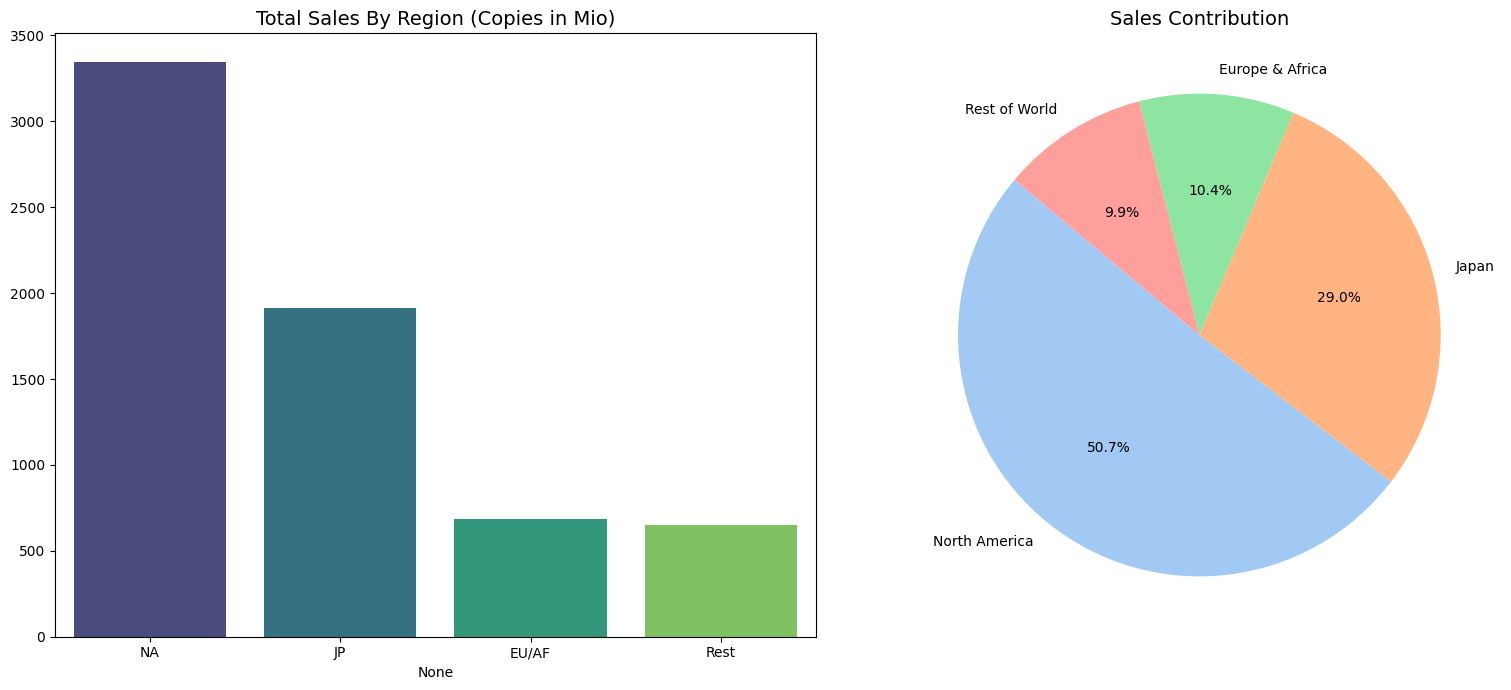

In [14]:
# Sales Distribution By Region

regions = ['North America Sales', 'Japan Sales', 'Europe & Africa Sales', 'Rest of World Sales']
total_region = df[regions].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=total_region.index, y=total_region.values, ax=ax[0], palette='viridis')
ax[0].set_title('Total Sales By Region (Copies in Mio)', fontsize=14)
ax[0].set_xticklabels(['NA', 'JP', 'EU/AF', 'Rest'], rotation=0)

ax[1].pie(total_region, labels=['North America', 'Japan', 'Europe & Africa', 'Rest of World'],
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
ax[1].set_title('Sales Contribution', fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_819/4153313721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_consoles.values, y=top_consoles.index, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_819/4153313721.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0,1], palette='magma')
/tmp/ipykernel_819/4153313721.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, ax=axes[1,0], palette='rocket')
/tmp/ipykernel_819/4153313721.py:23: FutureWarning: 

Passing `pale

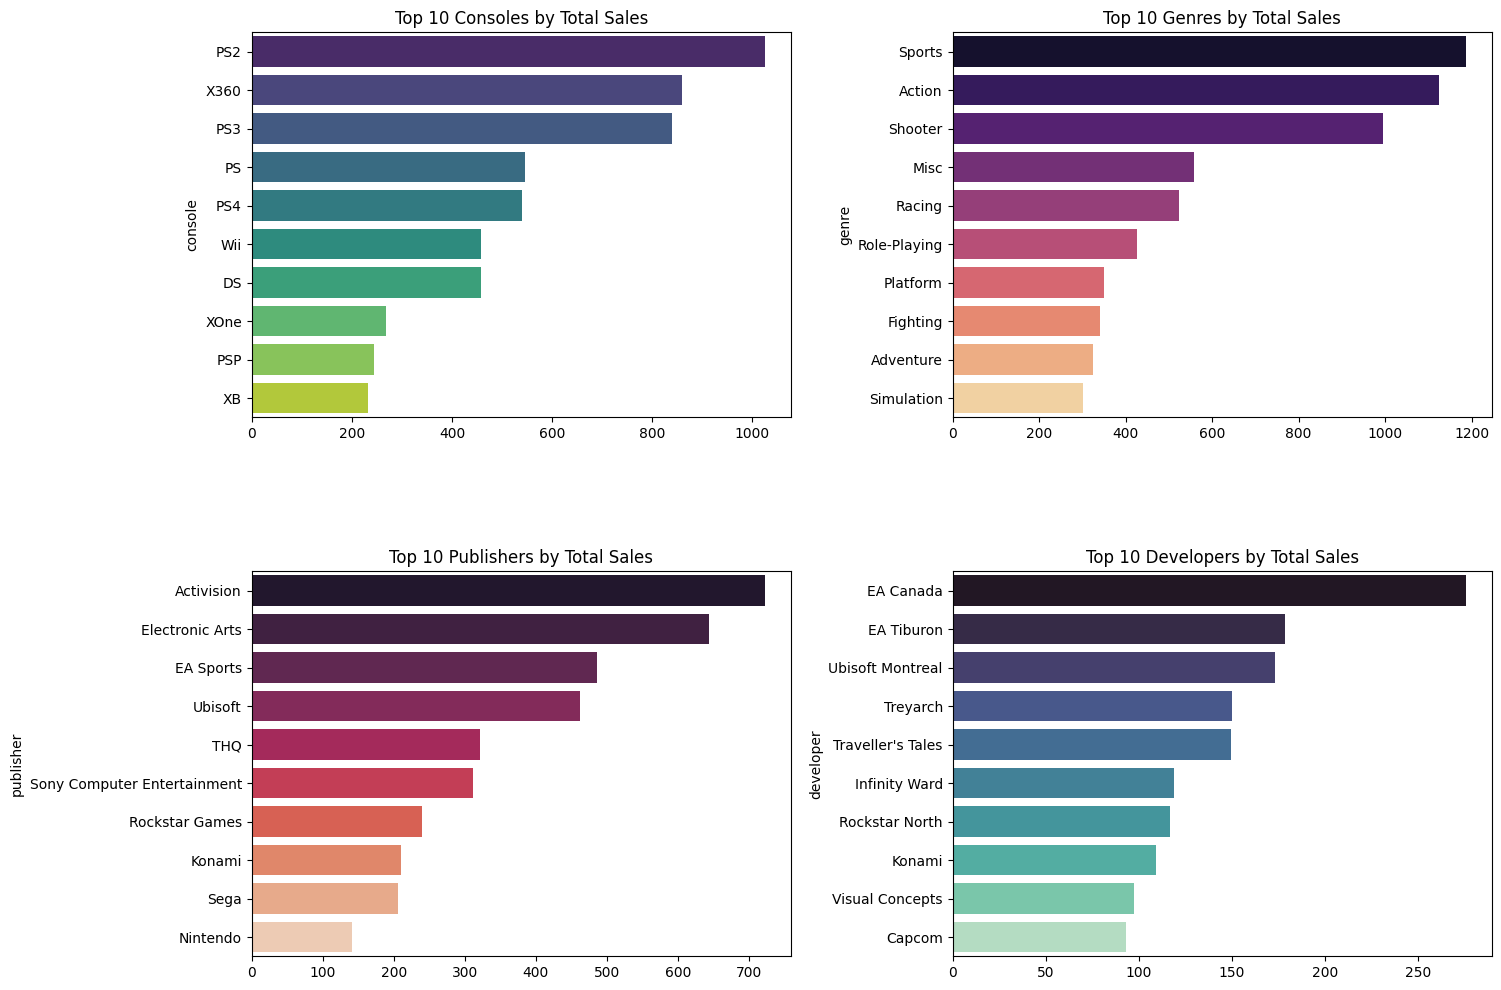

In [15]:
# Top Sales By Main Categories

def get_top_sales(df, column, top_n=10):
    return df.groupby(column)['total_sales'].sum().sort_values(ascending=False).head(top_n)

top_consoles = get_top_sales(df, 'console')
top_genres = get_top_sales(df, 'genre')
top_publishers = get_top_sales(df, 'publisher')
top_developers = get_top_sales(df, 'developer')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.barplot(x=top_consoles.values, y=top_consoles.index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Top 10 Consoles by Total Sales')

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0,1], palette='magma')
axes[0,1].set_title('Top 10 Genres by Total Sales')

sns.barplot(x=top_publishers.values, y=top_publishers.index, ax=axes[1,0], palette='rocket')
axes[1,0].set_title('Top 10 Publishers by Total Sales')

sns.barplot(x=top_developers.values, y=top_developers.index, ax=axes[1,1], palette='mako')
axes[1,1].set_title('Top 10 Developers by Total Sales')

plt.show()

/tmp/ipykernel_819/1883507060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_console.values, y=top_10_console.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_819/1883507060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_console.values, y=top_10_console.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_819/1883507060.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_console.values, y=top_10_console.index, ax=axes[i], palette='viridis')
/tmp/ipykernel_819/1883507060.py:15: FutureWarning: 

Pass

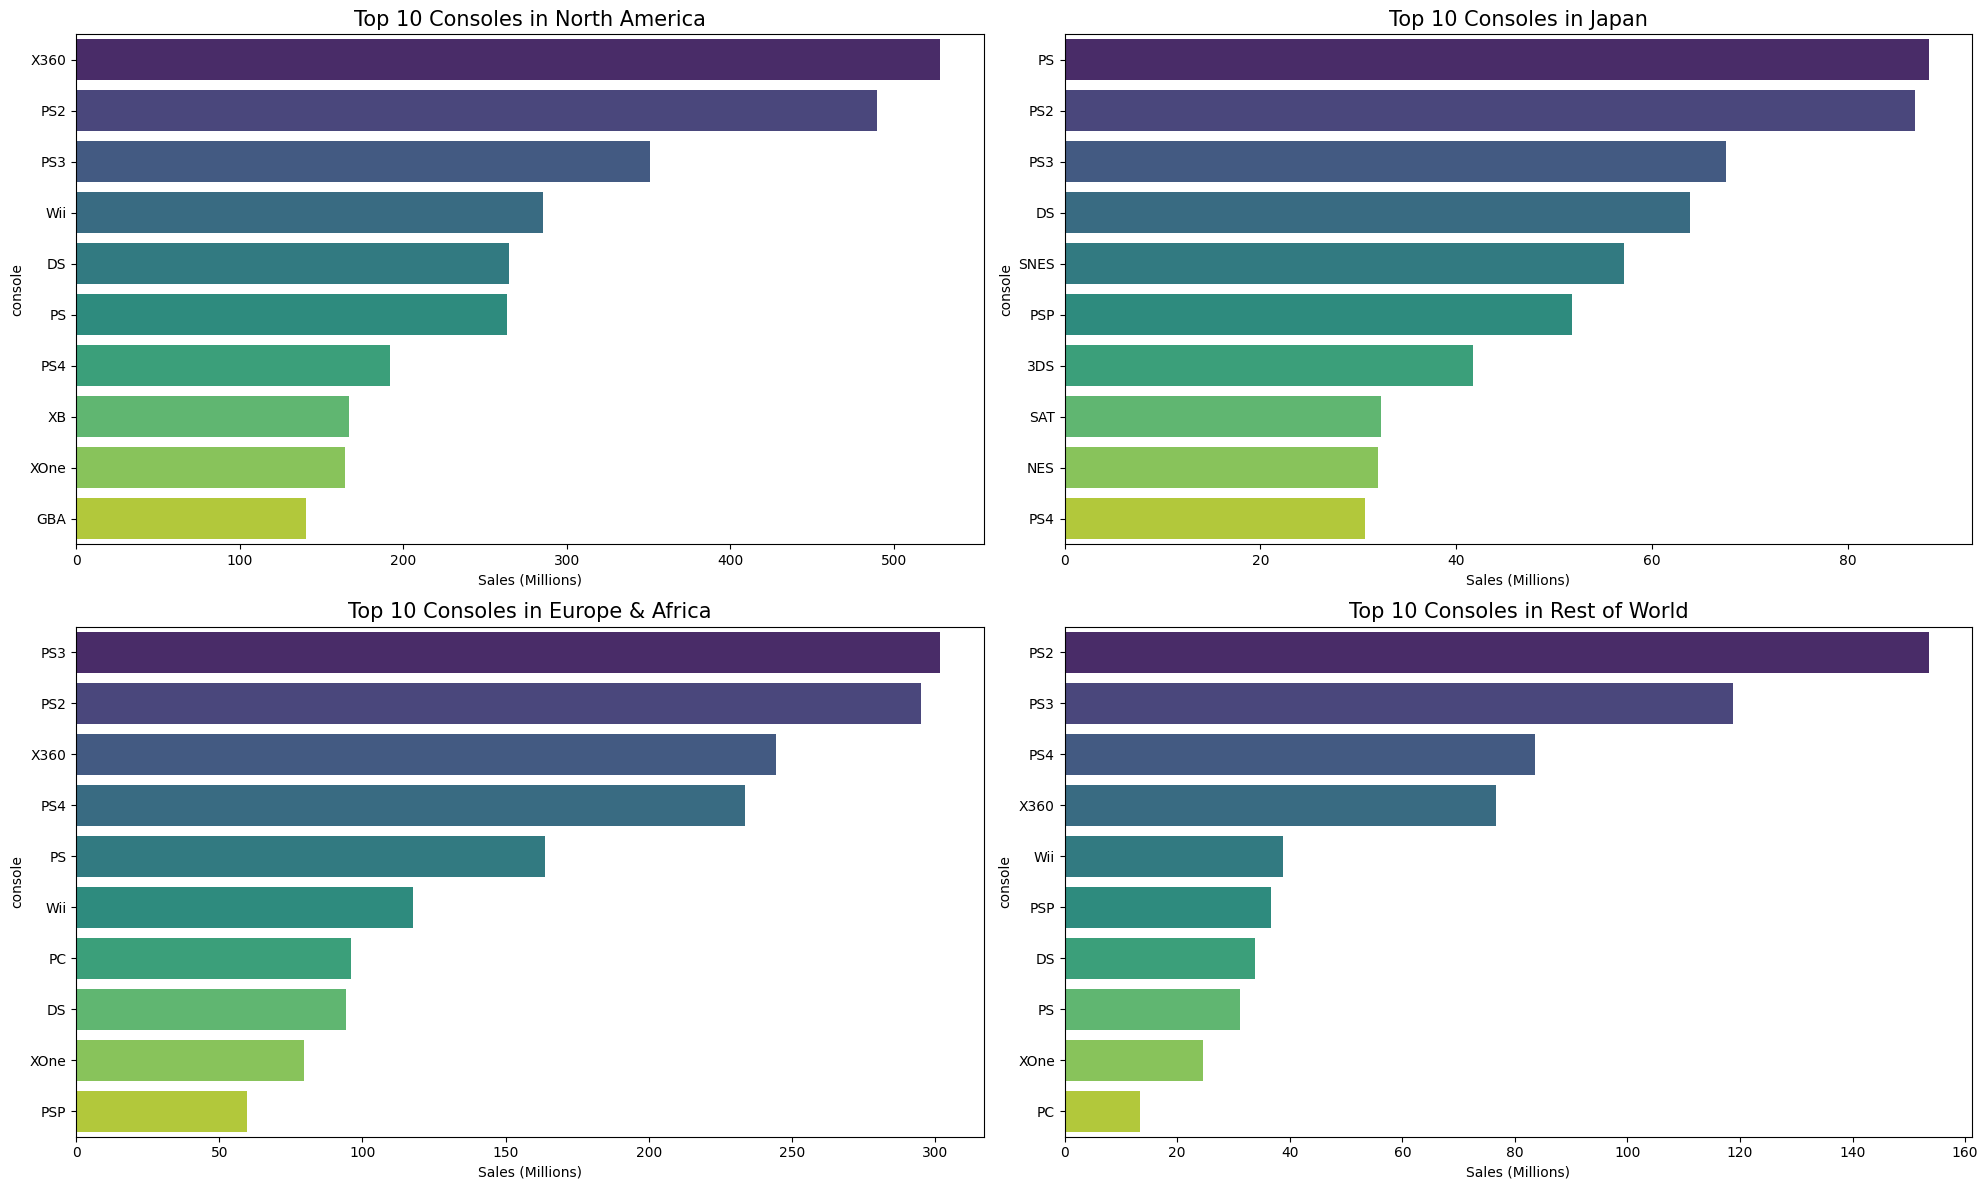

/tmp/ipykernel_819/1883507060.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genre.values, y=top_10_genre.index, ax=axes[i], palette='magma')
/tmp/ipykernel_819/1883507060.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genre.values, y=top_10_genre.index, ax=axes[i], palette='magma')
/tmp/ipykernel_819/1883507060.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genre.values, y=top_10_genre.index, ax=axes[i], palette='magma')
/tmp/ipykernel_819/1883507060.py:27: FutureWarning: 

Passing `palette` with

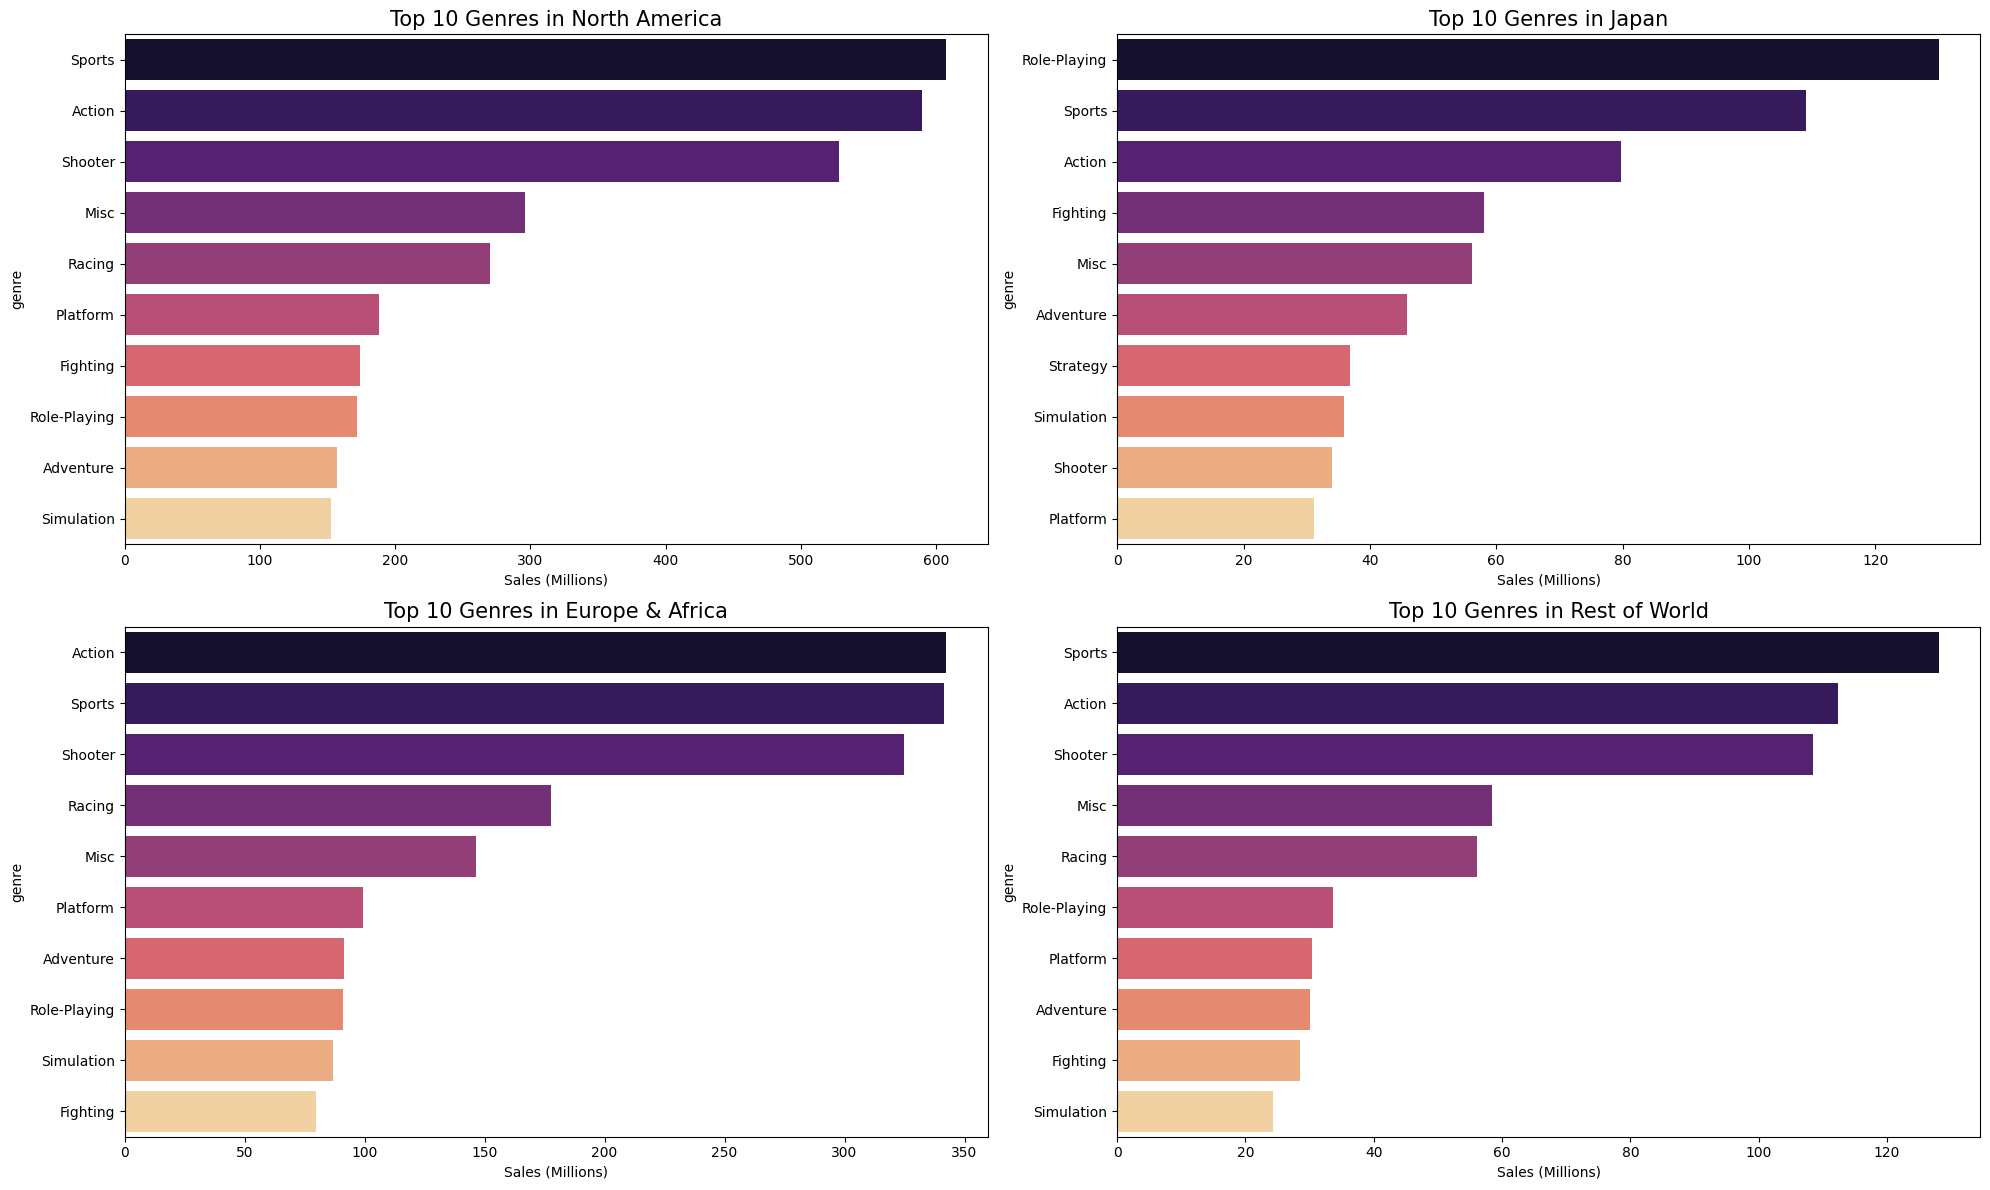

In [16]:
# Top 10 Console & Genre By Region

regions = {
    'North America Sales': 'North America',
    'Japan Sales': 'Japan',
    'Europe & Africa Sales': 'Europe & Africa',
    'Rest of World Sales': 'Rest of World'
}

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(regions.items()):
    top_10_console = df.groupby('console')[col].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_10_console.values, y=top_10_console.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 Consoles in {title}', fontsize=15)
    axes[i].set_xlabel('Sales (Millions)')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(regions.items()):
    top_10_genre = df.groupby('genre')[col].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_10_genre.values, y=top_10_genre.index, ax=axes[i], palette='magma')
    axes[i].set_title(f'Top 10 Genres in {title}', fontsize=15)
    axes[i].set_xlabel('Sales (Millions)')

plt.tight_layout()
plt.show()

Correlation Between Critic Score & Total Sales: 0.28


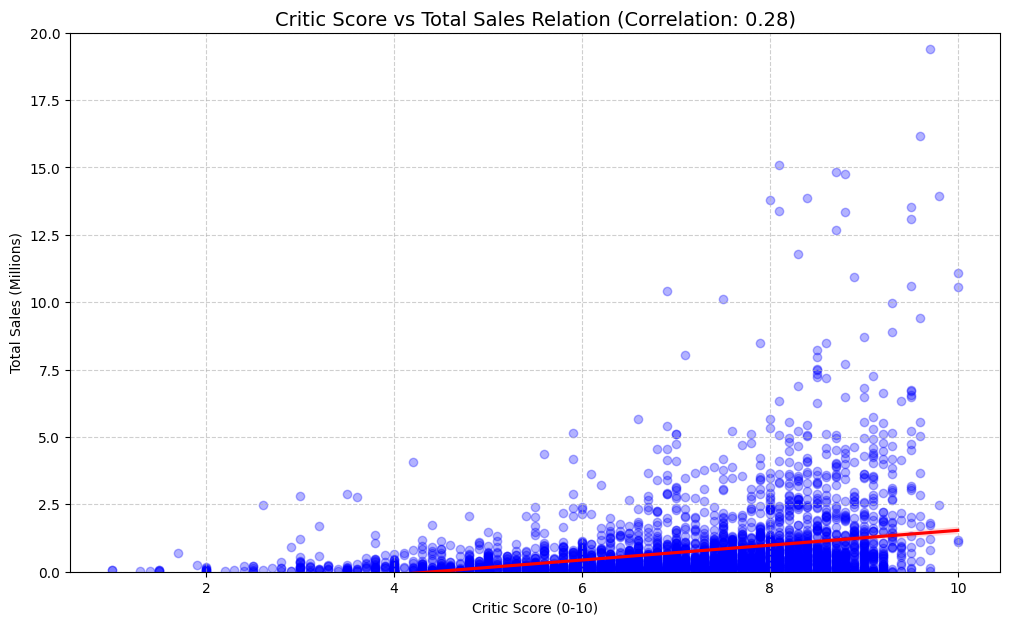

In [17]:
# Critic Score vs Total Sales Correlation

correlation = df['critic_score'].corr(df['total_sales'])
print(f"Correlation Between Critic Score & Total Sales: {correlation:.2f}")

plt.figure(figsize=(12, 7))

sns.regplot(data=df, x='critic_score', y='total_sales',
            scatter_kws={'alpha':0.3, 'color':'blue'},
            line_kws={'color':'red'})

plt.ylim(0, 20)

plt.title(f'Critic Score vs Total Sales Relation (Correlation: {correlation:.2f})', fontsize=14)
plt.xlabel('Critic Score (0-10)')
plt.ylabel('Total Sales (Millions)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
# Sales Cluster

from sklearn.cluster import KMeans

X = df[['total_sales']].values

kmeans = KMeans(n_clusters=4, random_state=42)
df['sales_cluster'] = kmeans.fit_predict(X)

print(df.groupby('sales_cluster')['total_sales'].agg(['min', 'max', 'count']))

                min    max  count
sales_cluster                    
0              0.00   0.69  16503
1              2.61   8.03    306
2              8.22  20.32     32
3              0.70   2.60   1991


In [19]:
# Sales Cluster Mapping

mapping = {
    0: 'Bronze',
    3: 'Silver',
    1: 'Gold',
    2: 'Platinum'
}

df['sales_category'] = df['sales_cluster'].map(mapping)

category_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
df['sales_category'] = pd.Categorical(df['sales_category'], categories=category_order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   img                        18832 non-null  object        
 1   title                      18832 non-null  object        
 2   console                    18832 non-null  object        
 3   genre                      18832 non-null  object        
 4   publisher                  18832 non-null  object        
 5   developer                  18832 non-null  object        
 6   critic_score               4123 non-null   float64       
 7   total_sales                18832 non-null  float64       
 8   North America Sales        12620 non-null  float64       
 9   Japan Sales                6688 non-null   float64       
 10  Europe & Africa Sales      12776 non-null  float64       
 11  Rest of World Sales        15071 non-null  float64       
 12  rele

  sales_category  total_games  games_with_score  score_available
0         Bronze        16503              2999        18.172453
1         Silver         1991               869        43.646409
2           Gold          306               227        74.183007
3       Platinum           32                28        87.500000
    Cluster  Average_Critic_Score
0    Bronze              6.839446
1    Silver              7.658803
2      Gold              8.217621
3  Platinum              8.871429


/tmp/ipykernel_819/1708703072.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=average_scores, x='Cluster', y='Average_Critic_Score', palette='magma')


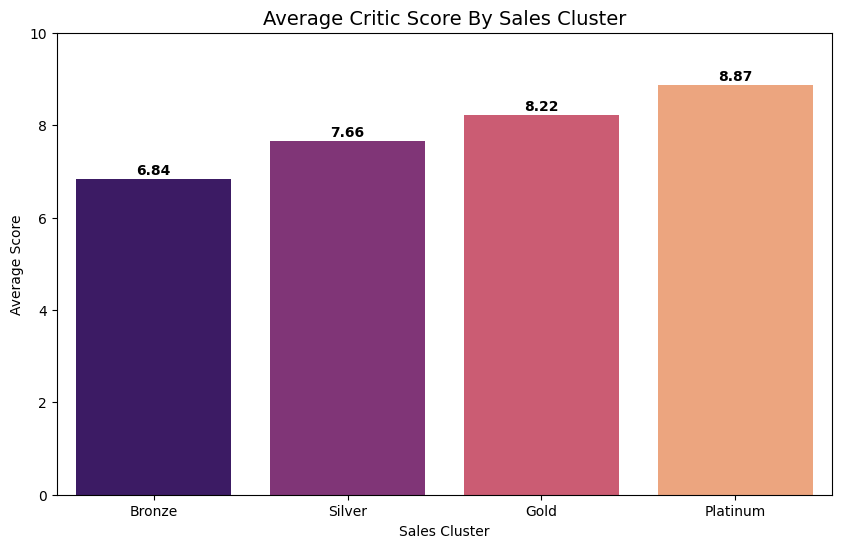

In [20]:
# Critic Score By Sales Cluster

score_check = df.groupby('sales_category', observed=True).agg(
    total_games=('title', 'count'),
    games_with_score=('score_status', 'sum')
).reset_index()

score_check['score_available'] = (score_check['games_with_score'] / score_check['total_games']) * 100

print(score_check)

average_scores = df[df['critic_score'].notna()].groupby('sales_category', observed=True)['critic_score'].mean().reset_index()

average_scores.columns = ['Cluster', 'Average_Critic_Score']
print(average_scores)

plt.figure(figsize=(10, 6))
sns.barplot(data=average_scores, x='Cluster', y='Average_Critic_Score', palette='magma')

plt.title('Average Critic Score By Sales Cluster', fontsize=14)
plt.ylim(0, 10)
plt.ylabel('Average Score')
plt.xlabel('Sales Cluster')

for i, val in enumerate(average_scores['Average_Critic_Score']):
    plt.text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

plt.show()

Publisher in Platinum Cluster:
                Publisher  Number_of_Game  Platinum_Cluster_Sales 
0              Activision              15                   183.62
6          Rockstar Games               9                   129.14
1      Bethesda Softworks               2                    17.36
2               EA Sports               2                    20.02
3         Electronic Arts               2                    20.09
4  Microsoft Game Studios               1                     9.97
5       Microsoft Studios               1                     9.96


/tmp/ipykernel_819/560215033.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=publisher_counts, x='Number_of_Game', y='Publisher', palette='viridis')


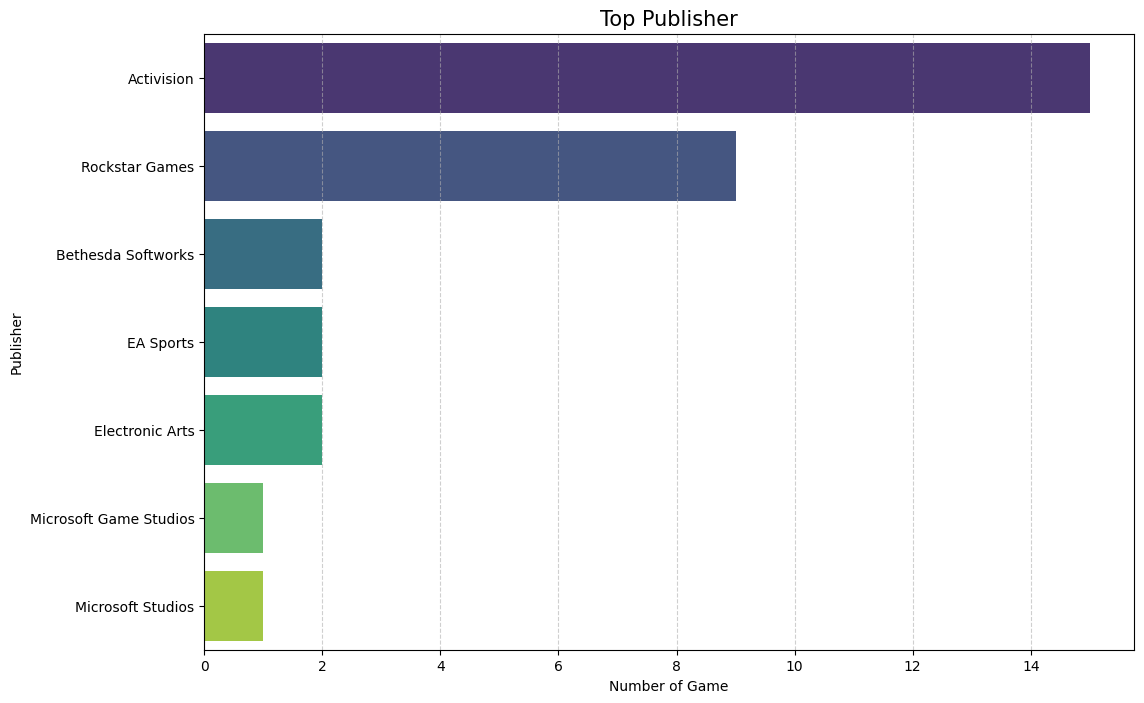

In [21]:
# Top Publisher

platinum_games = df[df['sales_category'] == 'Platinum']

publisher_counts = platinum_games.groupby('publisher')['total_sales'].agg(['count', 'sum']).reset_index()
publisher_counts.columns = ['Publisher', 'Number_of_Game', 'Platinum_Cluster_Sales ']
publisher_counts = publisher_counts.sort_values(by='Number_of_Game', ascending=False)

print("Publisher in Platinum Cluster:")
print(publisher_counts)

plt.figure(figsize=(12, 8))
sns.barplot(data=publisher_counts, x='Number_of_Game', y='Publisher', palette='viridis')

plt.title('Top Publisher', fontsize=15)
plt.xlabel('Number of Game')
plt.ylabel('Publisher')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [26]:
# Visualization Data Preparation (Wide)

!pip install gspread pandas gspread_dataframe

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
from gspread_dataframe import set_with_dataframe

creds, _ = default()
gc = gspread.authorize(creds)

sh = gc.create('Video Game Sales Dashboard')
worksheet = sh.sheet1

set_with_dataframe(worksheet, df)

print(sh.url)

https://docs.google.com/spreadsheets/d/1tEACtInasfQiUZTLgHyviFHZ-uZJJ0lVfSiRv_NpxCQ


In [27]:
# Data Frame Pivoting

columns_to_keep = ['title', 'publisher', 'console', 'sales_category', 'critic_score']

sales_columns = ['North America Sales', 'Japan Sales', 'Europe & Africa Sales', 'Rest of World Sales']

df_regional = pd.melt(
    df,
    id_vars=columns_to_keep,
    value_vars=sales_columns,
    var_name='region',
    value_name='sales_amount'
)

print("Data Original (Baris):", len(df))
print("Data Regional (Baris):", len(df_regional))

df_regional.info()

Data Original (Baris): 18832
Data Regional (Baris): 75328
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75328 entries, 0 to 75327
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   title           75328 non-null  object  
 1   publisher       75328 non-null  object  
 2   console         75328 non-null  object  
 3   sales_category  75328 non-null  category
 4   critic_score    16492 non-null  float64 
 5   region          75328 non-null  object  
 6   sales_amount    47155 non-null  float64 
dtypes: category(1), float64(2), object(4)
memory usage: 3.5+ MB


In [28]:
# Visualization Data Preparation (Long)

!pip install gspread gspread_dataframe

import gspread
from google.colab import auth
from google.auth import default
from gspread_dataframe import set_with_dataframe

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

sh = gc.create('Video Game Sales - Regional Pivot')

worksheet = sh.sheet1
worksheet.update_title('regional_sales_long_format')

set_with_dataframe(worksheet, df_regional)

print(sh.url)

https://docs.google.com/spreadsheets/d/1NsdUeCWMBXqQ5nZi3-s4hEEiNVJkR3WuPCIckOQw8vo
